# Phần 1. NumPy trong workflow ML/DL

Các bài dưới đây dùng dữ liệu nhỏ để mô phỏng preprocessing, inference và xử lý
tensor trong một pipeline thực tế.

In [23]:
STUDENT_NAME = "Nguyễn Long Thiên" 
STUDENT_ID = "25122089"   

print(f"Student: {STUDENT_NAME} ({STUDENT_ID})")

Student: Nguyễn Long Thiên (25122089)


In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (8, 4.8)

DATA_CANDIDATES = [
    Path("week02/numpy-pandas-eda-hw/data/automobile_raw.csv"),
    Path("data/automobile_raw.csv"),
    Path("../data/automobile_raw.csv"),
]
DATA_PATH = next((path for path in DATA_CANDIDATES if path.exists()), None)
if DATA_PATH is None:
    raise FileNotFoundError("Không tìm thấy data/automobile_raw.csv")

print("Data path:", DATA_PATH.resolve())

Data path: C:\Users\Admin\mliot-pyml-2026-hw\week02\numpy-pandas-eda-hw\data\automobile_raw.csv


## N1. Stable softmax cho batch logits

Một classifier trả về `logits` có shape `(batch_size, num_classes)`. Tính softmax
theo từng mẫu bằng cách trừ giá trị lớn nhất trên mỗi hàng trước khi gọi `np.exp`.
Cách viết này tránh overflow khi logits có giá trị lớn.

**Biến đầu ra bắt buộc**

- `shifted_logits`: logits sau khi trừ row-wise maximum.
- `class_probabilities`: xác suất mỗi class, mỗi hàng có tổng bằng 1.
- `predicted_classes`: class có xác suất lớn nhất của từng mẫu.
- `confidence_scores`: xác suất lớn nhất của từng mẫu.

In [25]:
logits = np.array([
    [2.0, 1.0, 0.1],
    [1000.0, 1001.0, 999.0],
    [-2.0, -1.0, 3.0],
    [0.5, 0.5, 0.5],
], dtype=np.float64)

In [48]:
shifted_logits = logits - np.max(logits, axis=1, keepdims=True)
exp_logits = np.exp(shifted_logits)
class_probabilities = exp_logits / np.sum(exp_logits, axis=1, keepdims=True)
predicted_classes = np.argmax(class_probabilities, axis=1)
confidence_scores = np.max(class_probabilities, axis=1)

In [47]:
required = [
    "shifted_logits",
    "class_probabilities",
    "predicted_classes",
    "confidence_scores",
]
if not all(name in globals() for name in required):
    print("Complete N1 to run this self-check.")
else:
    assert class_probabilities.shape == logits.shape
    assert np.all(np.isfinite(class_probabilities))
    assert np.allclose(class_probabilities.sum(axis=1), 1.0)
    assert predicted_classes.shape == (logits.shape[0],)
    assert confidence_scores.shape == (logits.shape[0],)
    print("N1 self-check passed")

N1 self-check passed


## N2. Chuẩn hóa train và validation không gây leakage

Mỗi hàng là một mẫu, mỗi cột là một feature. Tính mean/std **chỉ từ `X_train`**,
sau đó dùng cùng thống kê để transform cả train và validation.

**Biến đầu ra bắt buộc**

- `train_feature_mean`, `train_feature_std`: shape `(4,)`.
- `X_train_scaled`: train set đã chuẩn hóa.
- `X_val_scaled`: validation set dùng thống kê từ train.

In [27]:
# Features: height_cm, weight_kg, activity_hours, age
X_train = np.array([
    [170.0, 65.0, 1.2, 22.0],
    [180.0, 80.0, 2.4, 35.0],
    [160.0, 50.0, 0.8, 19.0],
    [175.0, 70.0, 1.5, 28.0],
    [168.0, 60.0, 1.0, 24.0],
    [182.0, 90.0, 3.0, 41.0],
])

X_val = np.array([
    [172.0, 68.0, 1.4, 26.0],
    [190.0, 95.0, 3.4, 45.0],
])

In [50]:
# TODO N2
train_feature_mean = np.mean(X_train, axis=0)
train_feature_std = np.std(X_train, axis=0)
X_train_scaled = (X_train - train_feature_mean) / train_feature_std
X_val_scaled = (X_val - train_feature_mean) / train_feature_std

In [49]:
required = [
    "train_feature_mean",
    "train_feature_std",
    "X_train_scaled",
    "X_val_scaled",
]
if not all(name in globals() for name in required):
    print("Complete N2 to run this self-check.")
else:
    assert X_train_scaled.shape == X_train.shape
    assert X_val_scaled.shape == X_val.shape
    assert np.allclose(X_train_scaled.mean(axis=0), 0.0)
    assert np.allclose(X_train_scaled.std(axis=0), 1.0)
    print("N2 self-check passed")

N2 self-check passed


## N3. Tạo review queue sau inference

Giả sử `class_probabilities` đến từ N1. Một prediction cần được kiểm tra thủ công
nếu dự đoán sai **hoặc** confidence nhỏ hơn `0.70`.

**Biến đầu ra bắt buộc**

- `correct_mask`
- `high_confidence_mask`
- `review_mask`
- `review_indices`

In [51]:
true_labels = np.array([0, 2, 2, 1])
confidence_threshold = 0.70

In [52]:
correct_mask = predicted_classes == true_labels
high_confidence_mask = confidence_scores >= confidence_threshold
review_mask = ~correct_mask | ~high_confidence_mask
review_indices = np.where(review_mask)[0]

## N4. Tiền xử lý và augment một batch ảnh

`image_batch_uint8` có layout `(B, H, W, C)`. Chuyển batch về `float32` trong đoạn
`[0, 1]`, sau đó tạo một batch mới được flip ngang. Batch augment phải có bộ nhớ
độc lập để việc chỉnh sửa không làm thay đổi batch đã normalize.

Sau khi tạo batch augment, đặt pixel `augmented_batch[0, 0, 0, 0] = 1.0`.

**Biến đầu ra bắt buộc:** `normalized_batch`, `augmented_batch`.

In [54]:
image_batch_uint8 = (
    np.arange(2 * 4 * 4 * 3, dtype=np.uint8)
    .reshape(2, 4, 4, 3)
)

In [55]:
normalized_batch = image_batch_uint8.astype(np.float32) / 255.0
augmented_batch = np.flip(normalized_batch, axis=2).copy()
augmented_batch[0, 0, 0, 0] = 1.0

# Phần 2. EDA với Automobile

Đọc `data/data_dictionary.md` trước khi xử lý.

## Câu hỏi mở đầu

1. Mỗi dòng đại diện cho đối tượng gì?
2. Ký hiệu missing value trong CSV là gì?
3. `symboling` có ý nghĩa gì?

**Trả lời**

1. Mỗi dòng đại diện cho một mẫu xe cụ thể trong bộ dữ liệu 1985 Auto Imports.
2. Ký hiệu missing value trong file CSV là dấu chấm hỏi `?`.
3. `symboling` thể hiện mức độ rủi ro bảo hiểm được gán cho xe, nhận giá trị từ -3 đến +3 .

## D1. Load và inspect raw CSV

Load dữ liệu sao cho dấu `?` vẫn là chuỗi để quan sát ảnh hưởng tới dtype.

**Biến đầu ra bắt buộc**

- `raw_df`: DataFrame raw.
- `raw_shape`: tuple.
- `raw_missing_marker_count`: tổng số dấu `?`.

In [58]:
raw_df = pd.read_csv(DATA_PATH)
raw_shape = raw_df.shape
print(raw_shape)
raw_missing_marker_count = (raw_df == "?").sum().sum()
print(f"missing values: {raw_missing_marker_count}")

(205, 26)
missing values: 59


## D2. Missing values và dtype

1. Thay `?` bằng `np.nan`.
2. Chuyển các cột trong `NUMERIC_COLUMNS` bằng `pd.to_numeric`.
3. Tạo báo cáo missing.

**Biến đầu ra bắt buộc:** `df_clean`, `missing_by_column`.

In [34]:
NUMERIC_COLUMNS = ['symboling', 'normalized_losses', 'wheel_base', 'length', 'width', 'height', 'curb_weight', 'engine_size', 'bore', 'stroke', 'compression_ratio', 'horsepower', 'peak_rpm', 'city_mpg', 'highway_mpg', 'price']

In [60]:
df_clean = raw_df.replace("?", np.nan).copy()
for column in NUMERIC_COLUMNS:
    df_clean[column] = pd.to_numeric(df_clean[column])
missing_by_column = df_clean.isna().sum()
print(df_clean.dtypes)
print(missing_by_column)

symboling              int64
normalized_losses    float64
make                  object
fuel_type             object
aspiration            object
num_doors             object
body_style            object
drive_wheels          object
engine_location       object
wheel_base           float64
length               float64
width                float64
height               float64
curb_weight            int64
engine_type           object
num_cylinders         object
engine_size            int64
fuel_system           object
bore                 float64
stroke               float64
compression_ratio    float64
horsepower           float64
peak_rpm             float64
city_mpg               int64
highway_mpg            int64
price                float64
dtype: object
symboling             0
normalized_losses    41
make                  0
fuel_type             0
aspiration            0
num_doors             2
body_style            0
drive_wheels          0
engine_location       0
wheel_base      

### Giải thích cách làm sạch dữ liệu

- Vì sao không nên fill tất cả numeric columns bằng cùng một giá trị?
- Với `price`, lựa chọn drop hay fill phù hợp hơn cho bài EDA này? Vì sao?
- `normalized_losses` thiếu nhiều dữ liệu hơn các cột khác. Điều này ảnh hưởng thế nào?

**Nhận xét**

- Không nên điền tất cả các cột numeric bằng cùng một giá trị vì mỗi cột có phân phối, đơn vị và tầm giá trị vật lý hoàn toàn khác nhau. Việc điền cùng giá trị sẽ làm sai lệch nghiêm trọng phân phối và các phân tích thống kê.
- Với cột `price`, lựa chọn drop phù hợp hơn vì đây là biến mục tiêu quan trọng và số lượng dòng thiếu rất ít (chỉ 4 mẫu). Điền giá trị giả định (như mean hay median) có thể làm giảm tính biến động thực tế của giá xe.
- Cột `normalized_losses` thiếu 41 dòng dữ liệu tức khoảng 20%.

## D3. DataFrame sang NumPy

Dùng sáu cột trong `AUTO_FEATURES`. Drop các dòng thiếu ít nhất một trong
sáu cột, sau đó chuyển sang `float64` NumPy array và chuẩn hóa theo feature.

**Biến đầu ra bắt buộc**

- `analysis_df`
- `X_auto`
- `auto_feature_mean`
- `auto_feature_std`
- `X_auto_scaled`

In [36]:
AUTO_FEATURES = ['curb_weight', 'engine_size', 'horsepower', 'city_mpg', 'highway_mpg', 'price']

In [62]:
analysis_df = df_clean[AUTO_FEATURES].dropna()
X_auto = analysis_df.to_numpy(dtype=np.float64)
auto_feature_mean = np.mean(X_auto, axis=0)
auto_feature_std = np.std(X_auto, axis=0)
X_auto_scaled = (X_auto - auto_feature_mean) / auto_feature_std

## D4. Outlier theo price z-score

Tính z-score của `price` bằng NumPy. Một dòng được xem là outlier trong bài
này khi `abs(z) > 2`.

**Biến đầu ra bắt buộc:** `price_z`, `price_outlier_mask`, `price_outliers`.

In [64]:
price_index = AUTO_FEATURES.index('price')
# price_z = ...
price_z = X_auto_scaled[ : , price_index]
# price_outlier_mask = ...
price_outlier_mask = np.abs(price_z) > 2
# price_outliers = ...
price_outliers = analysis_df[price_outlier_mask]
print(price_outliers)
print(X_auto_scaled[price_outlier_mask])

     curb_weight  engine_size  horsepower  city_mpg  highway_mpg    price
15          3230          209       182.0        16           22  30760.0
16          3380          209       182.0        16           22  41315.0
17          3505          209       182.0        15           20  36880.0
47          4066          258       176.0        15           19  32250.0
48          4066          258       176.0        15           19  35550.0
49          3950          326       262.0        13           17  36000.0
70          3770          183       123.0        22           25  31600.0
71          3740          234       155.0        16           18  34184.0
72          3685          234       155.0        16           18  35056.0
73          3900          308       184.0        14           16  40960.0
74          3715          304       184.0        14           16  45400.0
126         2756          194       207.0        17           25  32528.0
127         2756          194       20

## D5. Correlation và GroupBy

**Biến đầu ra bắt buộc**

- `engine_price_corr`: Pearson correlation tính bằng NumPy.
- `price_by_body_style`: Series mean price theo `body_style`, sort index.

In [65]:
# TODO D5
# engine_price_corr = ...
corr_matrix = np.corrcoef(X_auto_scaled, rowvar=False)
engine_price_corr = corr_matrix[AUTO_FEATURES.index('engine_size')][AUTO_FEATURES.index('price')]
print(f"engine_price_corr = {engine_price_corr}")
# price_by_body_style = ...
price_by_body_style = df_clean.groupby(by=['body_style'])['price'].mean().sort_values()
print(price_by_body_style)

engine_price_corr = 0.8738869517981525
body_style
hatchback       9957.441176
wagon          12371.960000
sedan          14459.755319
convertible    21890.500000
hardtop        22208.500000
Name: price, dtype: float64


# Phần 3. Visualization và insight

Mỗi biểu đồ cần:

1. một câu hỏi;
2. title, axis labels và unit;
3. lựa chọn chart phù hợp;
4. 1--2 câu nhận xét ngay dưới chart.

## M2.1 Price phân phối như thế nào?

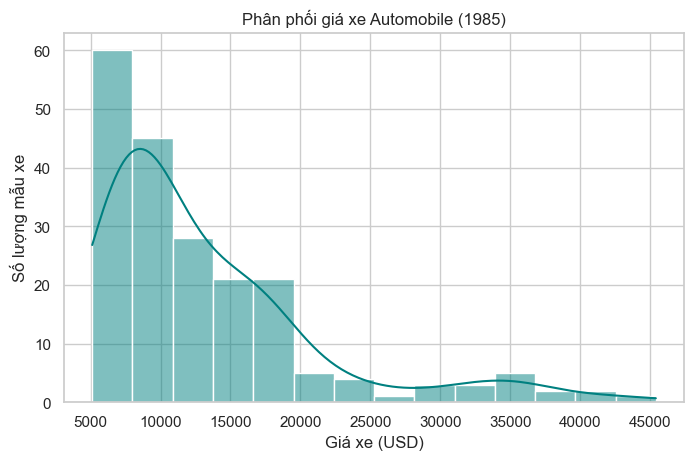

In [66]:
sns.histplot(data=df_clean, x="price", kde=True, color="teal")
plt.title("Phân phối giá xe Automobile (1985)")
plt.xlabel("Giá xe (USD)")
plt.ylabel("Số lượng mẫu xe")
plt.show()

**Nhận xét:** Phân phối giá xe bị lệch phải rõ rệt. Phần lớn các mẫu xe tập trung ở phân khúc giá rẻ và trung bình dưới 15,000 USD, trong khi số lượng mẫu xe cao cấp có giá trên 25,000 USD là rất ít.

## M2.2 Dataset có cân bằng theo body style không?

C:\Users\Admin\AppData\Local\Temp\ipykernel_20584\66192869.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_clean, x="body_style", order=df_clean["body_style"].value_counts().index, palette="viridis")


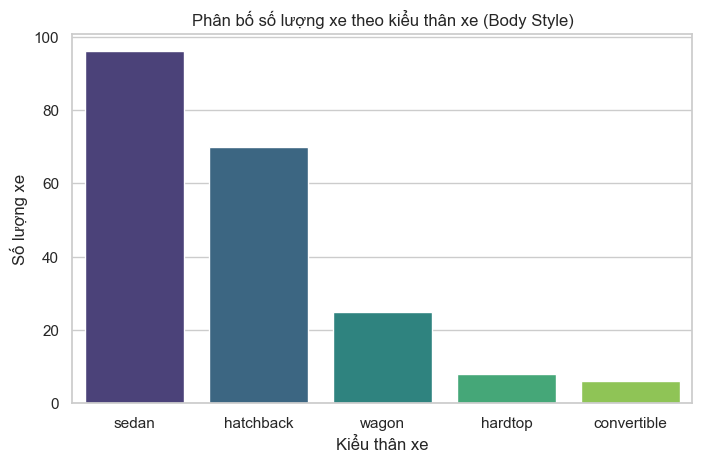

In [67]:
sns.countplot(data=df_clean, x="body_style", order=df_clean["body_style"].value_counts().index, palette="viridis")
plt.title("Phân bố số lượng xe theo kiểu thân xe (Body Style)")
plt.xlabel("Kiểu thân xe")
plt.ylabel("Số lượng xe")
plt.show()

**Nhận xét:** Bộ dữ liệu không cân bằng về kiểu thân xe. Kiểu dáng sedan và hatchback chiếm đa số tuyệt đối, trong khi kiểu dáng convertible và hardtop có số lượng cực kỳ hạn chế.

## M2.3 Price khác nhau theo body style ra sao?

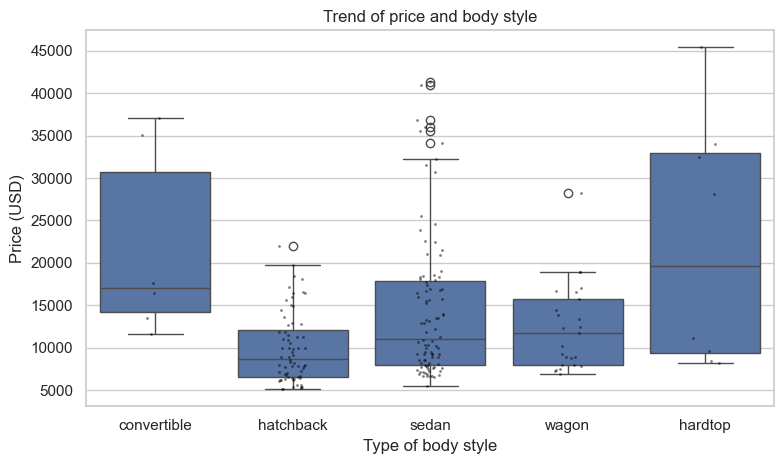

In [68]:
# TODO M2.3: boxplot price theo body_style
sns.boxplot(data=df_clean, x='body_style', y='price')
sns.stripplot(data=df_clean, x='body_style', y='price', alpha=0.5, color='black', size=2)
plt.xlabel("Type of body style")
plt.ylabel("Price (USD)")
plt.title("Trend of price and body style")
plt.tight_layout()
plt.show()

**Nhận xét:** Kiểu dáng hardtop và convertible có giá trung vị cao nhất cùng dải giá biến động rộng. Sedan và hatchback có mức giá trung vị thấp hơn, nhưng sedan xuất hiện nhiều giá trị ngoại lai ở phân khúc rất đắt tiền.

## M2.4 Engine size liên quan thế nào tới price?

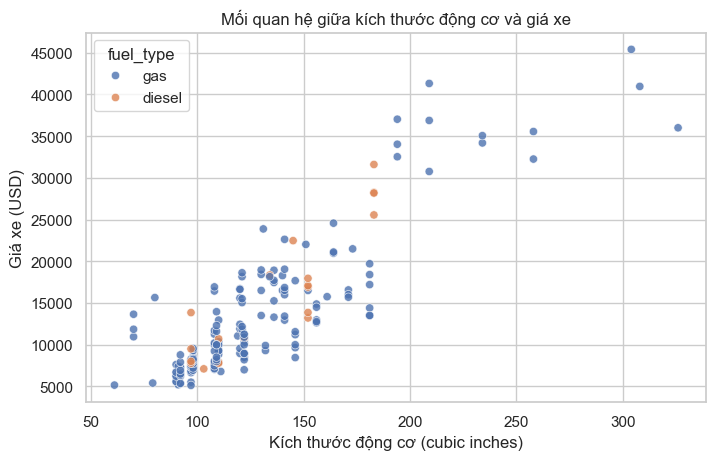

In [43]:
sns.scatterplot(data=df_clean, x="engine_size", y="price", hue="fuel_type", alpha=0.8)
plt.title("Mối quan hệ giữa kích thước động cơ và giá xe")
plt.xlabel("Kích thước động cơ (cubic inches)")
plt.ylabel("Giá xe (USD)")
plt.show()

**Nhận xét:** Có mối tương quan thuận mạnh mẽ và rõ rệt giữa kích thước động cơ và giá xe, nghĩa là động cơ càng lớn thì xe càng đắt. Xu hướng này đúng cho cả xe chạy xăng (gas) và chạy dầu (diesel).

## M2.5 Các feature numeric tương quan ra sao?

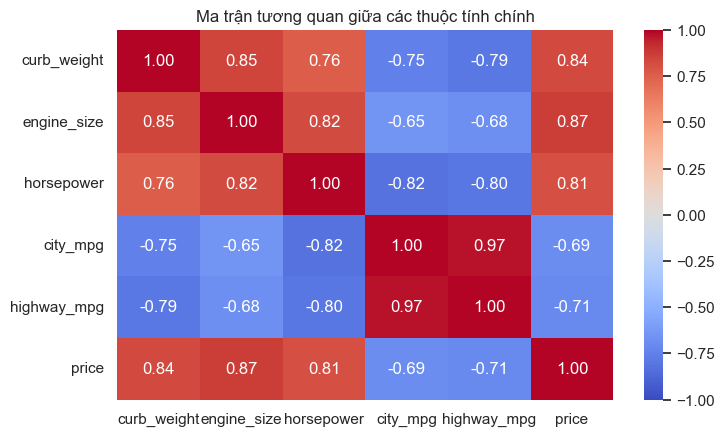

In [44]:
corr_matrix = analysis_df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
plt.title("Ma trận tương quan giữa các thuộc tính chính")
plt.show()

**Nhận xét:** Giá xe (`price`) tương quan thuận rất mạnh với `engine_size` (0.87), `horsepower` (0.81) và `curb_weight` (0.83). Ngược lại, giá xe tương quan nghịch mạnh với hiệu suất nhiên liệu (`city_mpg` và `highway_mpg`).

## M2.6 Biểu đồ tự chọn

Đặt một câu hỏi mới, chọn chart phù hợp và không lặp nguyên năm biểu đồ trên.

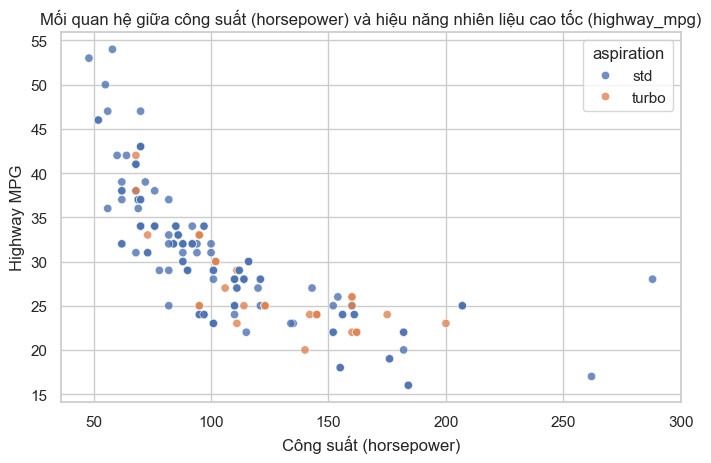

In [45]:
sns.scatterplot(data=df_clean, x="horsepower", y="highway_mpg", hue="aspiration", alpha=0.8)
plt.title("Mối quan hệ giữa công suất (horsepower) và hiệu năng nhiên liệu cao tốc (highway_mpg)")
plt.xlabel("Công suất (horsepower)")
plt.ylabel("Highway MPG")
plt.show()

**Nhận xét:** Có mối tương quan nghịch rõ rệt giữa công suất động cơ và hiệu suất nhiên liệu cao tốc. Xe có công suất càng cao thì càng tiêu tốn nhiên liệu nhiều hơn (MPG thấp). Xe sử dụng turbo nạp khí thường có công suất cao hơn.

# Tổng hợp

Viết:

- 3--5 phát hiện chính có dẫn chứng;
- ít nhất 2 hạn chế của dataset;
- một ví dụ về correlation không đồng nghĩa causation;
- một câu hỏi nên phân tích tiếp.

## Tổng hợp của sinh viên

### Phát hiện chính:
1. Giá xe tương quan rất mạnh với kích thước động cơ (r ≈ 0.87) và khối lượng xe (r ≈ 0.83).
2. Xe có công suất (`horsepower`) càng cao thì hiệu suất nhiên liệu (`highway_mpg`) càng thấp.
3. Phần lớn xe nhập khẩu tập trung ở phân khúc bình dân (dưới 15,000 USD).
4. Các dòng xe mui trần (`convertible`) và mui cứng (`hardtop`) thuộc phân khúc giá cao nhất.

### Hạn chế của bộ dữ liệu:
1. Dữ liệu từ năm 1985 nên quá cũ, không phản ánh công nghệ xe hiện đại (EV, hybrid).
2. Cột `normalized_losses` khuyết thiếu tới 20% dữ liệu.

### Tương quan
- Khối lượng xe (`curb_weight`) tương quan thuận với giá xe (`price`), nhưng không có nghĩa là cứ làm xe nặng thêm (như chất đá lên xe) thì xe sẽ đắt hơn. Giá đắt thực chất do vật liệu cao cấp và động cơ mạnh mẽ làm tăng cả khối lượng lẫn giá trị.

### Câu hỏi phân tích tiếp:
- Cơ chế nạp khí (`aspiration`) ảnh hưởng như thế nào đến giá bán và mức độ bảo hiểm của xe theo từng hãng?